In [121]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LinearRegression
import sqlite3
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from statsmodels.regression.linear_model import OLS
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

pd.read_csv('Virat-Kohli-International-Cricket-Centuries.csv')

,No.,Runs,Against,Position,Innings,Venue,Ground,Date,Result
0,1,107,Sri Lanka,4,2,"Eden Gardens, Kolkata",Home,24-Dec-09,Won
1,2,102*,Bangladesh,3,2,"Sher-e-Bangla Cricket Stadium, Dhaka",Away,11-Jan-10,Won
2,3,118,Australia,3,2,"APCA-VDCA Stadium, Visakhapatnam",Home,20-Oct-10,Won
3,4,105,New Zealand,3,1,"Nehru Stadium, Guwahati",Home,28-Nov-10,Won
4,5,100*,Bangladesh,4,1,"Sher-e-Bangla Cricket Stadium, Dhaka",Away,19-Feb-11,Won
...,...,...,...,...,...,...,...,...,...
75,76,121,West Indies,4,1,"Queen's Park Oval, Port of Spain",Away,20-Jul-23,Drawn
76,77,122*,Pakistan,3,1,"R. Premadasa Stadium, Colombo",Neutral,11-Sep-23,Won
77,78,103*,Bangladesh,3,2,"Maharashtra Cricket Association Stadium, Pune",Home,19-Oct-23,Won
78,79,101*,South Africa,3,1,"Eden Gardens, Kolkata",NaN,05-Nov,Won


In [4]:
Kohli = pd.read_csv('Virat-Kohli-International-Cricket-Centuries.csv')

In [5]:
Kohli.columns

Kohli.count()

No.         80
Runs        80
Against     80
Position    80
Innings     80
Venue       80
Ground      79
Date        80
Result      80
dtype: int64

In [6]:
Kohli['No.'].mean()

40.5

In [7]:
Kohli['Runs'] = Kohli['Runs'].str.replace('*', '', regex=False)
Kohli['Runs'] = pd.to_numeric(Kohli['Runs'])

# Display the DataFrame
print(Kohli['Runs'])

0     107
1     102
2     118
3     105
4     100
     ... 
75    121
76    122
77    103
78    101
79    117
Name: Runs, Length: 80, dtype: int64


In [8]:
Kohli

,No.,Runs,Against,Position,Innings,Venue,Ground,Date,Result
0,1,107,Sri Lanka,4,2,"Eden Gardens, Kolkata",Home,24-Dec-09,Won
1,2,102,Bangladesh,3,2,"Sher-e-Bangla Cricket Stadium, Dhaka",Away,11-Jan-10,Won
2,3,118,Australia,3,2,"APCA-VDCA Stadium, Visakhapatnam",Home,20-Oct-10,Won
3,4,105,New Zealand,3,1,"Nehru Stadium, Guwahati",Home,28-Nov-10,Won
4,5,100,Bangladesh,4,1,"Sher-e-Bangla Cricket Stadium, Dhaka",Away,19-Feb-11,Won
...,...,...,...,...,...,...,...,...,...
75,76,121,West Indies,4,1,"Queen's Park Oval, Port of Spain",Away,20-Jul-23,Drawn
76,77,122,Pakistan,3,1,"R. Premadasa Stadium, Colombo",Neutral,11-Sep-23,Won
77,78,103,Bangladesh,3,2,"Maharashtra Cricket Association Stadium, Pune",Home,19-Oct-23,Won
78,79,101,South Africa,3,1,"Eden Gardens, Kolkata",NaN,05-Nov,Won


In [9]:
Kohli['Runs'].mean()



131.55

In [10]:
Kohli.std()

/var/folders/_l/4l0tlm8d2812gt5rf77kpy8c0000gp/T/ipykernel_23110/3902137890.py:1: FutureWarning: The default value of numeric_only in DataFrame.std is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  Kohli.std()


No.         23.237900
Runs        35.094772
Position     0.656033
Innings      0.670820
dtype: float64

Text(0, 0.5, 'Frequency')

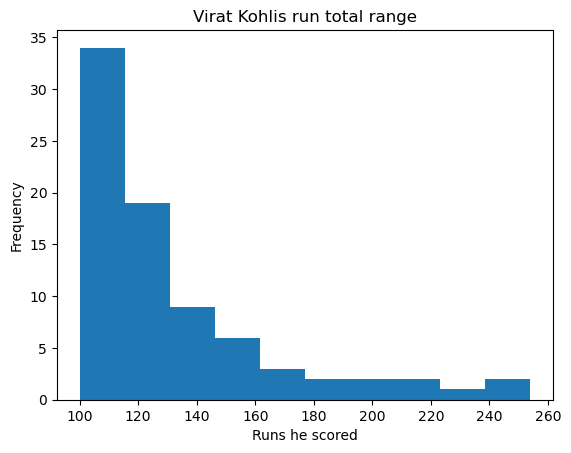

In [164]:
plt.hist(Kohli['Runs'])
plt.title("Virat Kohlis run total range")
plt.xlabel("Runs he scored")
plt.ylabel("Frequency")

In [12]:
Kohli.skew()

/var/folders/_l/4l0tlm8d2812gt5rf77kpy8c0000gp/T/ipykernel_23110/4269111098.py:1: FutureWarning: The default value of numeric_only in DataFrame.skew is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  Kohli.skew()


No.         0.000000
Runs        1.800528
Position    0.965628
Innings     1.006710
dtype: float64

In [13]:
Kohli.kurtosis()

/var/folders/_l/4l0tlm8d2812gt5rf77kpy8c0000gp/T/ipykernel_23110/3665616734.py:1: FutureWarning: The default value of numeric_only in DataFrame.kurt is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  Kohli.kurtosis()


No.        -1.200000
Runs        2.867002
Position    1.601497
Innings     1.941350
dtype: float64

In [14]:
SriLanka = print("Centuries against SL:", Kohli['Against'].str.contains('Sri Lanka').sum())
WI = print("Centuries against WI:", Kohli['Against'].str.contains('West Indies').sum()) 
Pakistan = print("Centuries against Pakistan:", Kohli['Against'].str.contains('Pakistan').sum())
NewZ = print("Centuries against New Zealand:",Kohli['Against'].str.contains('New Zealand').sum())
Aus = print("Centuries against Australia:", Kohli['Against'].str.contains('Australia').sum())
SA = print("Centuries against South Africa:", Kohli['Against'].str.contains('South Africa').sum())
Ban = print("Centuries against Bandgladesh:", Kohli['Against'].str.contains('Bangladesh').sum())
Eng = print("Centuries against England:", Kohli['Against'].str.contains('England').sum())
Afg = print("Centuries against Afganistan:",Kohli['Against'].str.contains('Afghanistan').sum())
Zim = print("Centuries against Zimbabwe", Kohli['Against'].str.contains('Zimbabwe').sum())





#count_sri_lanka = df['Against'].str.contains('Sri Lanka').sum()


Centuries against SL: 15
Centuries against WI: 12
Centuries against Pakistan: 3
Centuries against New Zealand: 9
Centuries against Australia: 16
Centuries against South Africa: 8
Centuries against Bandgladesh: 7
Centuries against England: 8
Centuries against Afganistan: 1
Centuries against Zimbabwe 1


Text(0.5, 1.0, 'Pie Distrubution of Content Type')

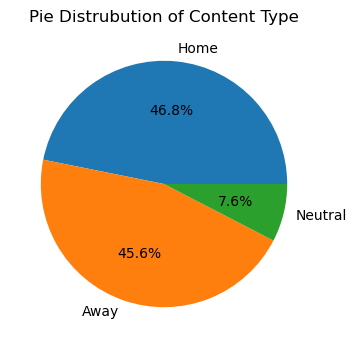

In [15]:
total_type = Kohli['Ground'].value_counts()

plt.figure(figsize=(8,4))
plt.pie(total_type, labels=total_type.index, autopct='%1.1f%%')
plt.title("Pie Distrubution of Content Type")

#No impact whether it plays at home or away

Text(0.5, 1.0, 'Pie Distrubution of Content Type')

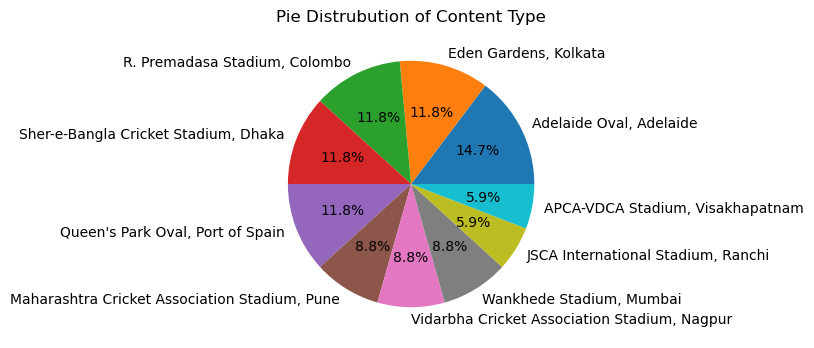

In [16]:
total_type = Kohli['Venue'].value_counts().head(10)

plt.figure(figsize=(8,4))
plt.pie(total_type, labels=total_type.index, autopct='%1.1f%%')
plt.title("Pie Distrubution of Content Type")

#Likes playing in the Adelaide oval the most. 

In [17]:
conn = sqlite3.connect(':memory:')  # or use 'kohli.db' for a file-based DB
Kohli.to_sql('centuries', conn, index=False, if_exists='replace')


80

In [41]:
query1 = "SELECT Against, COUNT(*) AS total_centuries FROM centuries GROUP BY Against ORDER BY total_centuries DESC"
result = pd.read_sql_query(query1, conn)

result

,Against,total_centuries
0,Australia,16
1,Sri Lanka,15
2,West Indies,11
3,New Zealand,8
4,England,8
5,South Africa,7
6,Bangladesh,6
7,Pakistan,2
8,West Indies,1
9,South Africa,1


Text(0.5, 1.0, 'Virat Kohli Centuries by specific team')

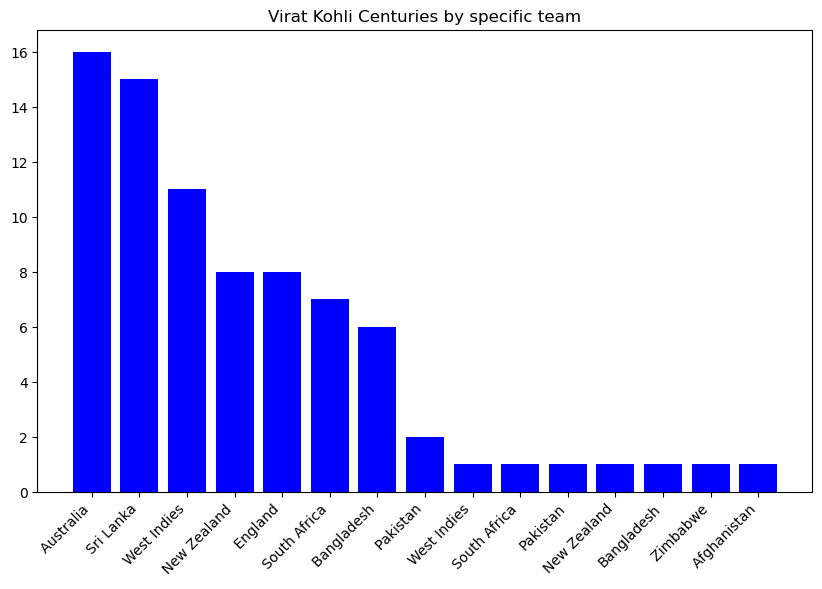

In [39]:
plt.figure(figsize=(10,6))

# Plot the bar chart using data from the query result
plt.bar(result['Against'], result['total_centuries'], color='blue')
plt.xticks(rotation=45, ha='right')
plt.title("Virat Kohli Centuries by specific team")



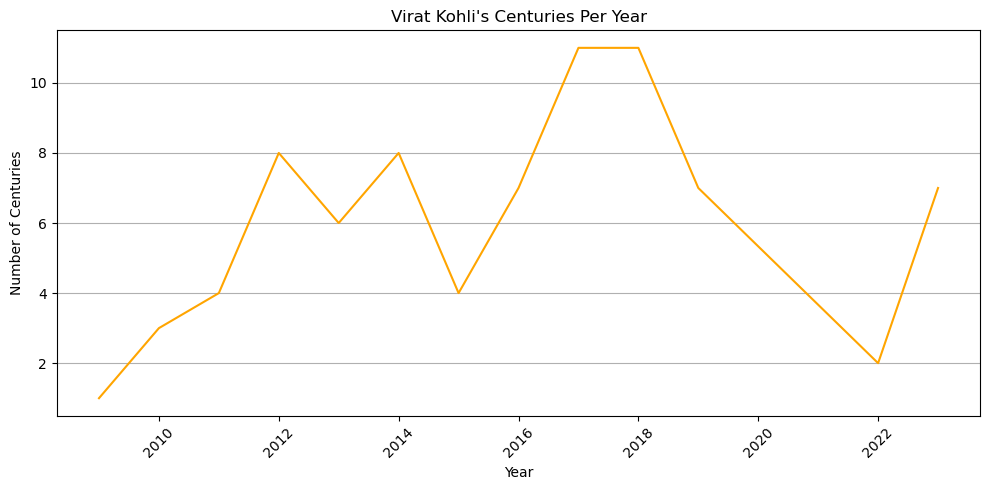

In [74]:
query2 = "SELECT Date FROM centuries"
result2 = pd.read_sql_query(query2, conn)
result2

result2['Date'] = pd.to_datetime(result2['Date'], errors='coerce')

# Extract year
result2['Year'] = result2['Date'].dt.year

# Count centuries per year
centuries_per_year = result2['Year'].value_counts().sort_index()

# Show the result
#print(centuries_per_year)

plt.figure(figsize=(10, 5))
centuries_per_year.plot(kind='line', color='orange')

plt.xlabel("Year")
plt.ylabel("Number of Centuries")
plt.title("Virat Kohli's Centuries Per Year")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [ ]:
#Filter off tests and ODIS/T20Is
#Should be good 


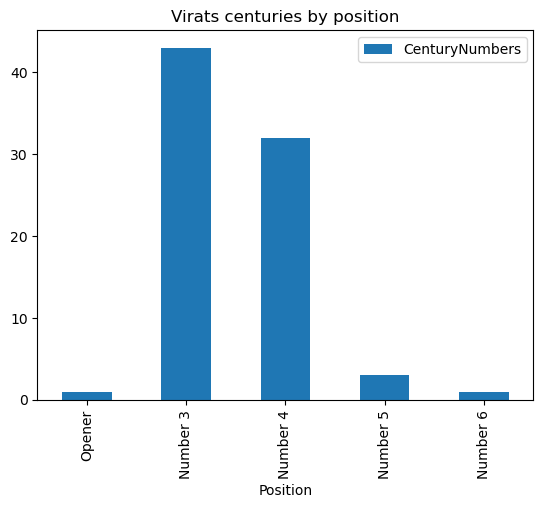

In [165]:
Filtered_Kohli = Kohli[Kohli['Position'] == 6]
Filtered_Kohli.count()
#1 Century when he opened the innings
#43 Centuries when he batted at number 3
#32 Centuries when he batted at number 4
#3 Centuries when he batted at number 5
#1 Century when he batted at number 6

data = {'Position': ["Opener", 'Number 3', 'Number 4', 'Number 5', "Number 6"]
       , 'CenturyNumbers': [1, 43, 32, 3, 1]}

df = pd.DataFrame(data)
df.plot.bar(x='Position', y='CenturyNumbers')
plt.title('Virats centuries by position')
plt.show()


In [167]:
categorical_cols = ['Against', 'Venue', 'Result']
encoder = OneHotEncoder(sparse=False, drop='first')  # drop='first' to avoid multicollinearity
encoded = encoder.fit_transform(Kohli[categorical_cols])
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(categorical_cols))
Kohli_encoded = pd.concat([Kohli.drop(columns=categorical_cols), encoded_df], axis=1)

print(Kohli_encoded)

    No.  Runs  Position  Innings   Ground       Date    Year  \
0     1   107         4        2     Home 2009-12-24  2009.0   
1     2   102         3        2     Away 2010-01-11  2010.0   
2     3   118         3        2     Home 2010-10-20  2010.0   
3     4   105         3        1     Home 2010-11-28  2010.0   
4     5   100         4        1     Away 2011-02-19  2011.0   
..  ...   ...       ...      ...      ...        ...     ...   
75   76   121         4        1     Away 2023-07-20  2023.0   
76   77   122         3        1  Neutral 2023-09-11  2023.0   
77   78   103         3        2     Home 2023-10-19  2023.0   
78   79   101         3        1      NaN        NaT     NaN   
79   80   117         3        1     Home 2023-11-15  2023.0   

    Against_ Australia  Against_ Bangladesh  Against_ England  ...  \
0                  0.0                  0.0               0.0  ...   
1                  0.0                  1.0               0.0  ...   
2                  1.

/Users/Aravind/anaconda3/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [169]:
!export PATH=/Library/TeX/texbin:$PATH
